<a href="https://colab.research.google.com/github/nishthha01/nishthha01/blob/main/Heart_Failure_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

# Extract
zip_path = next(iter(uploaded))
extract_path = '/content/heart_dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Saving heart_failure_prediction.zip to heart_failure_prediction (2).zip
Extracted files: ['heart.csv']


In [21]:
import pandas as pd

df = pd.read_csv("heart_failure_prediction.zip")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [22]:
# Dataset shape and info
print("Shape:", df.shape)
print("\n Missing Values:\n", df.isnull().sum())
df.describe()
df.info()

Shape: (918, 12)

 Missing Values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    

In [23]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', fill_value=0)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [24]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# One-hot encode
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Encoded DataFrame shape:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Encoded DataFrame shape: (918, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [25]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (734, 15)
Testing samples: (184, 15)


In [43]:
# Baseline Train

In [44]:
# 1. SVM
from sklearn.svm import SVC

# Train
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [29]:
# Predict
y_train_svm = svm_model.predict(X_train)
y_test_svm = svm_model.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics

print("SVM - Training:")
print("Accuracy:", accuracy_score(y_train, y_train_svm))
print("Precision:", precision_score(y_train, y_train_svm))
print("Recall:", recall_score(y_train, y_train_svm))
print("F1 Score:", f1_score(y_train, y_train_svm))


print("\nKNN - Testing:")
print("Accuracy:", accuracy_score(y_test, y_test_svm))
print("Precision:", precision_score(y_test, y_test_svm))
print("Recall:", recall_score(y_test, y_test_svm))
print("F1 Score:", f1_score(y_test, y_test_svm))

SVM - Training:
Accuracy: 0.720708446866485
Precision: 0.7583547557840618
Recall: 0.7266009852216748
F1 Score: 0.7421383647798742

KNN - Testing:
Accuracy: 0.717391304347826
Precision: 0.75
Recall: 0.7352941176470589
F1 Score: 0.7425742574257426


In [45]:
# 2. KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
# predict
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

# Metrics
print("KNN - Training:")
print("Accuracy:", accuracy_score(y_train, y_train_knn))
print("Precision:", precision_score(y_train, y_train_knn))
print("Recall:", recall_score(y_train, y_train_knn))
print("F1 Score:", f1_score(y_train, y_train_knn))

print("\nKNN - Testing:")
print("Accuracy:", accuracy_score(y_test, y_test_knn))
print("Precision:", precision_score(y_test, y_test_knn))
print("Recall:", recall_score(y_test, y_test_knn))
print("F1 Score:", f1_score(y_test, y_test_knn))

KNN - Training:
Accuracy: 0.7806539509536785
Precision: 0.7937649880095923
Recall: 0.8152709359605911
F1 Score: 0.804374240583232

KNN - Testing:
Accuracy: 0.6956521739130435
Precision: 0.7254901960784313
Recall: 0.7254901960784313
F1 Score: 0.7254901960784313


In [46]:
# 3. Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
# Predict
y_train_dt = dt_model.predict(X_train)
y_test_dt = dt_model.predict(X_test)

# Metrics
print("Decision Tree - Training:")
print("Accuracy:", accuracy_score(y_train, y_train_dt))
print("Precision:", precision_score(y_train, y_train_dt))
print("Recall:", recall_score(y_train, y_train_dt))
print("F1 Score:", f1_score(y_train, y_train_dt))

print("\nDecision Tree - Testing:")
print("Accuracy:", accuracy_score(y_test, y_test_dt))
print("Precision:", precision_score(y_test, y_test_dt))
print("Recall:", recall_score(y_test, y_test_dt))
print("F1 Score:", f1_score(y_test, y_test_dt))

Decision Tree - Training:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Decision Tree - Testing:
Accuracy: 0.7880434782608695
Precision: 0.7889908256880734
Recall: 0.8431372549019608
F1 Score: 0.8151658767772512


In [48]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
# Hyperparameter tuning models

In [50]:
# 1. Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

hyperparameters = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear', 'lbfgs']
}

# Grid Search with cross-validation
lr_grid = GridSearchCV(estimator=lr_model, param_grid=hyperparameters, cv=5, scoring='accuracy', n_jobs=-1)

lr_grid.fit(X_train, y_train)

bestModel = lr_grid.best_estimator_
print("Best Parameters:", lr_grid.best_params_)

Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}


In [51]:
# Predictions
lr_train_pred = bestModel.predict(X_train)
lr_test_pred = bestModel.predict(X_test)

# Evaluation on Training Set
print("\nLogistic Regression - Training Metrics")
print("Accuracy:", accuracy_score(y_train, lr_train_pred))
print("Precision:", precision_score(y_train, lr_train_pred))
print("Recall:", recall_score(y_train, lr_train_pred))
print("F1 Score:", f1_score(y_train, lr_train_pred))


# Evaluation on Test Set
print("\nLogistic Regression - Test Metrics")
print("Accuracy:", accuracy_score(y_test, lr_test_pred))
print("Precision:", precision_score(y_test, lr_test_pred))
print("Recall:", recall_score(y_test, lr_test_pred))
print("F1 Score:", f1_score(y_test, lr_test_pred))


Logistic Regression - Training Metrics
Accuracy: 0.8623978201634878
Precision: 0.863961813842482
Recall: 0.8916256157635468
F1 Score: 0.8775757575757576

Logistic Regression - Test Metrics
Accuracy: 0.8858695652173914
Precision: 0.8715596330275229
Recall: 0.9313725490196079
F1 Score: 0.9004739336492891


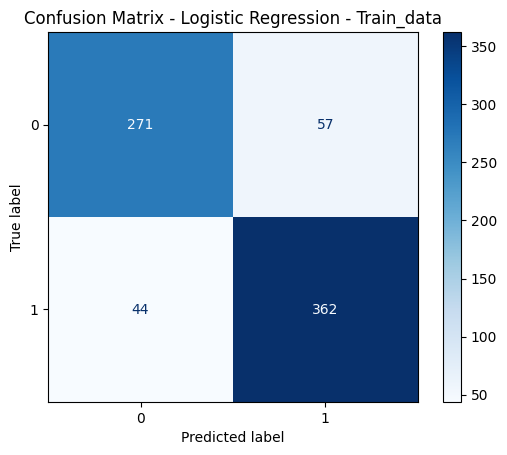

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#  Confusion matrix - LogisticR - Train
matrix = confusion_matrix(y_train, lr_train_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression - Train_data")
plt.show()

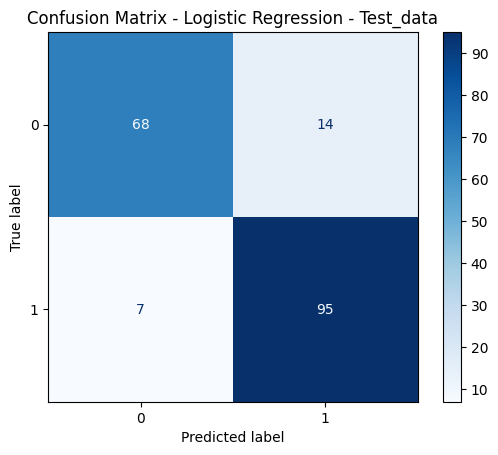

In [60]:
#  Confusion matrix - LogisticR - Test
matrix = confusion_matrix(y_test, lr_test_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression - Test_data")
plt.show()

In [56]:
# 2. K-Nearest Neighbors(KNN)
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Grid Search CV
knn_grid = GridSearchCV(knn_model, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print("Best KNN Params:", knn_grid.best_params_)
best_knn = knn_grid.best_estimator_

Best KNN Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [61]:
# predictions
knn_train_pred = best_knn.predict(X_train)
knn_test_pred = best_knn.predict(X_test)

# Evaluation on Training set
print("\nKNN - Training Metrics")
print("Accuracy:", accuracy_score(y_train, knn_train_pred))
print("Precision:", precision_score(y_train, knn_train_pred))
print("Recall:", recall_score(y_train, knn_train_pred))
print("F1 Score:", f1_score(y_train, knn_train_pred))

# Evaluation on Test Set
print("\nKNN - Test Metrics")
print("Accuracy:", accuracy_score(y_test, knn_test_pred))
print("Precision:", precision_score(y_test, knn_test_pred))
print("Recall:", recall_score(y_test, knn_test_pred))
print("F1 Score:", f1_score(y_test, knn_test_pred))


KNN - Training Metrics
Accuracy: 0.8801089918256131
Precision: 0.8714953271028038
Recall: 0.9187192118226601
F1 Score: 0.894484412470024

KNN - Test Metrics
Accuracy: 0.8913043478260869
Precision: 0.8867924528301887
Recall: 0.9215686274509803
F1 Score: 0.9038461538461539


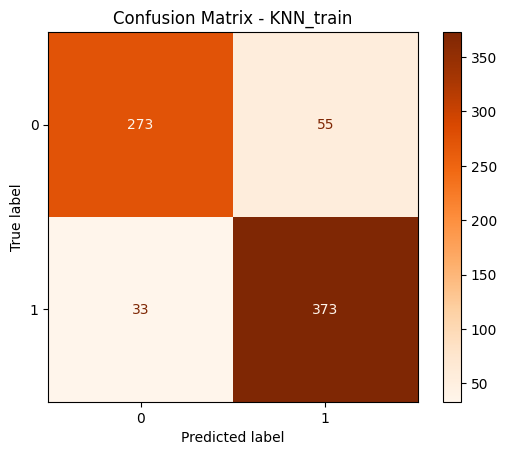

In [62]:
# Confusion matrix - knn Train
matrix = confusion_matrix(y_train, knn_train_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap='Oranges')
plt.title("Confusion Matrix - KNN_train")
plt.show()

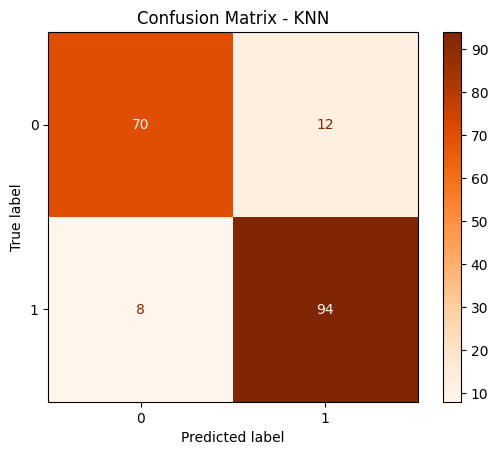

In [63]:
# confusion matrix - knn Test
matrix = confusion_matrix(y_test, knn_test_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap='Oranges')
plt.title("Confusion Matrix - KNN")
plt.show()

In [65]:
#  3. Support Vector Machine

from sklearn.svm import SVC

# SVM model (with probability=True for AUC)
svm_model = SVC(probability=True, random_state=42)

svm_params =  {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}
# GridSearchCV
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
best_svm = svm_grid.best_estimator_

Best SVM Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [66]:
# Predictions
svm_test_pred = best_svm.predict(X_test)
svm_train_pred = best_svm.predict(X_train)

# Evaluation on Training Set

print("\nSVM- Training Metrics")
print("Accuracy:", accuracy_score(y_train, svm_train_pred ))
print("Precision:", precision_score(y_train, svm_train_pred ))
print("Recall:", recall_score(y_train, svm_train_pred ))
print("F1 Score:", f1_score(y_train, svm_train_pred ))


# Evaluation on Test Set

print("\nSVM - Test Metrics")
print("Accuracy:", accuracy_score(y_test,svm_test_pred))
print("Precision:", precision_score(y_test, svm_test_pred))
print("Recall:", recall_score(y_test, svm_test_pred))
print("F1 Score:", f1_score(y_test, svm_test_pred))


SVM- Training Metrics
Accuracy: 0.9019073569482289
Precision: 0.8901869158878505
Recall: 0.9384236453201971
F1 Score: 0.9136690647482014

SVM - Test Metrics
Accuracy: 0.9021739130434783
Precision: 0.8818181818181818
Recall: 0.9509803921568627
F1 Score: 0.9150943396226415


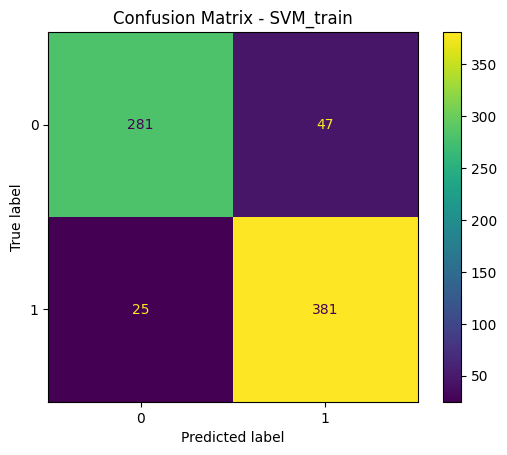

In [67]:
# Confusion matrix - svm train
matrix = confusion_matrix(y_train, svm_train_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot()
plt.title("Confusion Matrix - SVM_train")
plt.show()

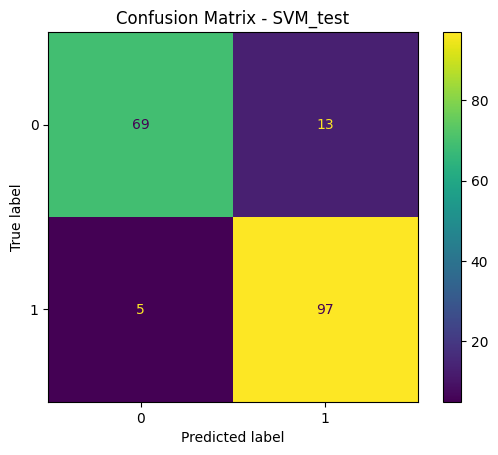

In [68]:
# Confusion matrix - svm test
matrix = confusion_matrix(y_test, svm_test_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot()
plt.title("Confusion Matrix - SVM_test")
plt.show()

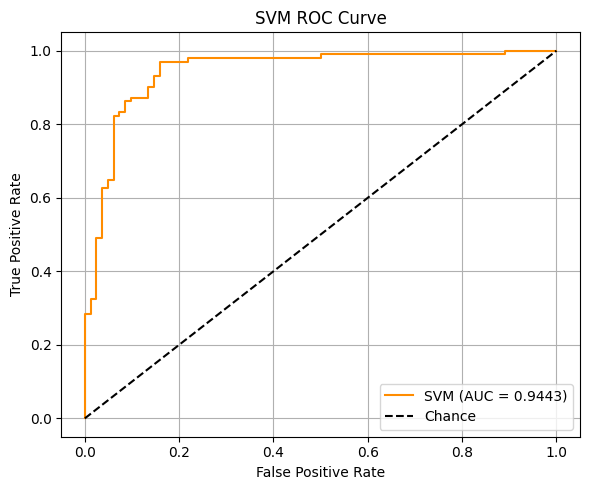

In [71]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities
svm_probs = best_svm.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, svm_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [72]:
import shap
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# SHAP explainer for SVM
explainer = shap.Explainer(best_svm.predict, X_train)

shap_values = explainer(X_test_df[:100])

PermutationExplainer explainer: 101it [01:26,  1.10it/s]


<ipython-input-73-ee89b519d15f>:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df[:100], plot_size=(10, 8))


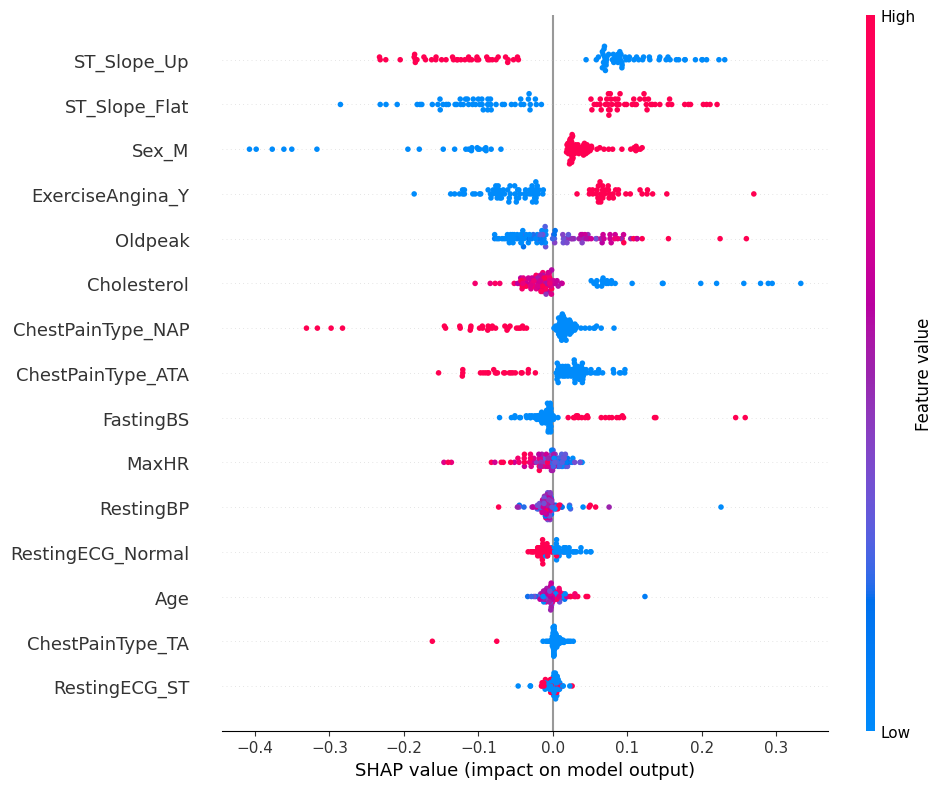

In [73]:
# Plot with feature names
shap.summary_plot(shap_values, X_test_df[:100], plot_size=(10, 8))

In [97]:
# 4. XGB model
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42)

xgb_params =  {
    "n_estimators" :[100,200],
    "max_depth": [4],
    "learning_rate": [0.05]
}

# GridSearchCV
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("Best xgb Params:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_

Best xgb Params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


In [98]:
# Predict
xgb_train_pred = best_xgb.predict(X_train)
xgb_test_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

# Evaluation on Training Set
print("\nXGB- Training Metrics")
print("Accuracy:", accuracy_score(y_train, xgb_train_pred ))
print("Precision:", precision_score(y_train, xgb_train_pred ))
print("Recall:", recall_score(y_train, xgb_train_pred ))
print("F1 Score:", f1_score(y_train, xgb_train_pred ))


# Evaluation on Test Set
print("\nXGB - Test Metrics")
print("Accuracy:", accuracy_score(y_test, xgb_test_pred))
print("Precision:", precision_score(y_test, xgb_test_pred))
print("Recall:", recall_score(y_test, xgb_test_pred))
print("F1 Score:", f1_score(y_test, xgb_test_pred))


XGB- Training Metrics
Accuracy: 0.9373297002724795
Precision: 0.9347826086956522
Recall: 0.9532019704433498
F1 Score: 0.9439024390243902

XGB - Test Metrics
Accuracy: 0.8858695652173914
Precision: 0.900990099009901
Recall: 0.8921568627450981
F1 Score: 0.896551724137931


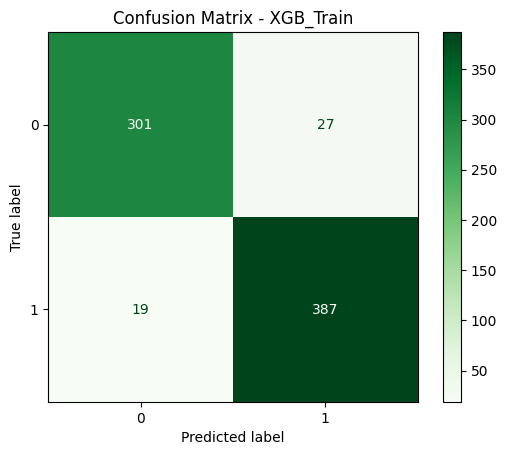

In [76]:
# Confusion matrix - XGB train
matrix = confusion_matrix(y_train, xgb_train_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap='Greens')
plt.title("Confusion Matrix - XGB_Train")
plt.show()

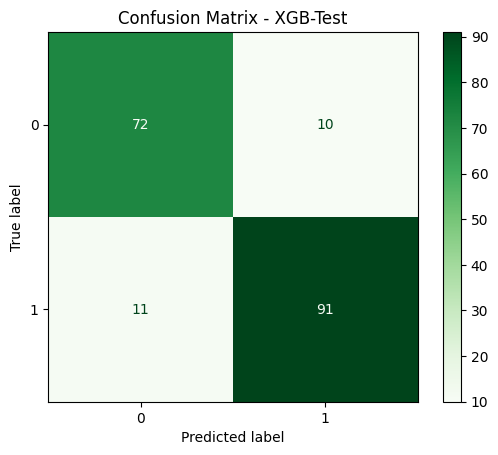

In [77]:
# Confusion matrix - Xgb test
matrix = confusion_matrix(y_test, xgb_test_pred)
graph = ConfusionMatrixDisplay(confusion_matrix=matrix)
graph.plot(cmap="Greens")
plt.title("Confusion Matrix - XGB-Test")
plt.show()

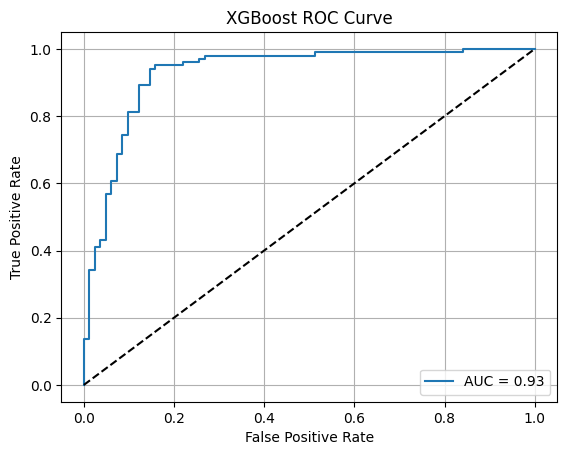

In [81]:
# ROC Curve of XGB
# Predicted probabilities
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

# ROC curve and plot
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

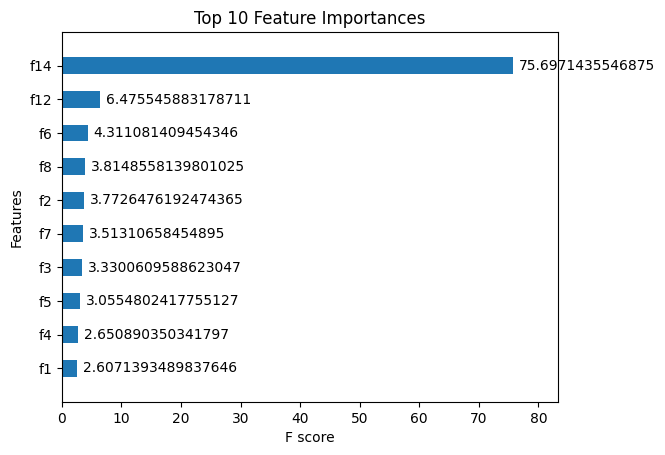

In [100]:
# Plot feature importance
import matplotlib.pyplot as plt

xgb.plot_importance(best_xgb, importance_type='gain', height=0.5, max_num_features=10, title="Top 10 Feature Importances")
plt.grid()
plt.show()

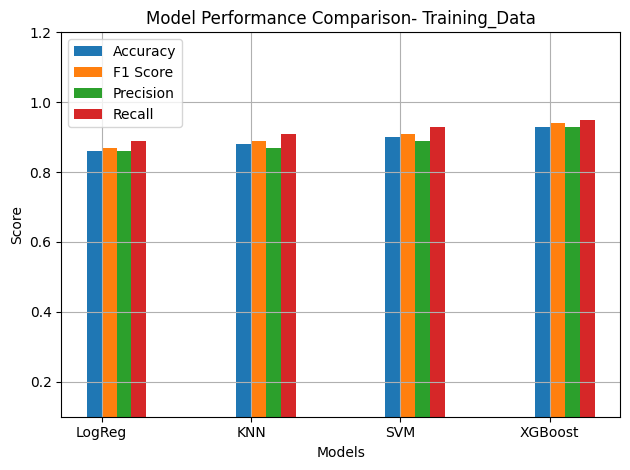

In [ ]:
# Comaprison between the 4 models Logistic regression , KNN, SVM, Xgb

import matplotlib.pyplot as plt

models = ['LogReg', 'KNN', 'SVM', 'XGBoost']
accuracy = [0.86, 0.88, 0.90, 0.93]
f1 = [0.87, 0.89, 0.91, 0.94]
precision = [0.86, 0.87, 0.89, 0.93]
recall = [0.89, 0.91, 0.93, 0.95]



x = range(len(models))
width = 0.10

plt.bar(x, accuracy, width=width, label='Accuracy')
plt.bar([i + width for i in x], f1, width=width, label='F1 Score')
plt.bar([i + 2 * width for i in x], precision, width=width, label='Precision')
plt.bar([i + 3 * width for i in x], recall, width=width, label='Recall')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison- Training_Data")
plt.xticks([i + width/2 for i in x], models)
plt.ylim(0.1, 1.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

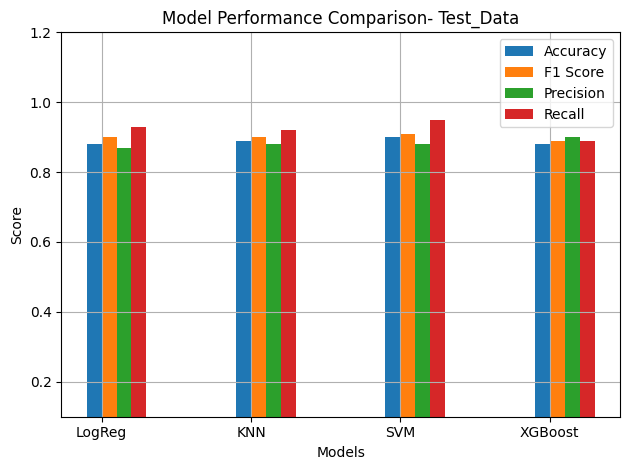

In [ ]:
models = ['LogReg', 'KNN', 'SVM', 'XGBoost']
accuracy = [0.88, 0.89, 0.90, 0.88]
precision = [0.87, 0.88, 0.88, 0.90]
recall = [0.93, 0.92, 0.95, 0.89]
f1 = [0.90, 0.90, 0.91, 0.89]


x = range(len(models))
width = 0.10

plt.bar(x, accuracy, width=width, label='Accuracy')
plt.bar([i + width for i in x], f1, width=width, label='F1 Score')
plt.bar([i + 2 * width for i in x], precision, width=width, label='Precision')
plt.bar([i + 3 * width for i in x], recall, width=width, label='Recall')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison- Test_Data")
plt.xticks([i + width/2 for i in x], models)
plt.ylim(0.1, 1.2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()